170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 287s 2us/step


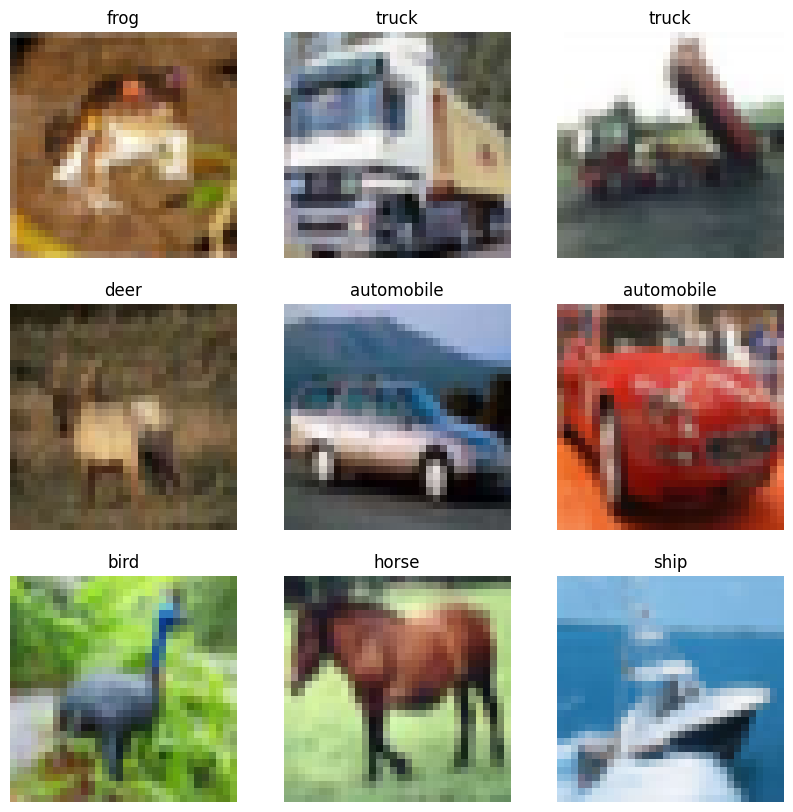

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,410 (3.40 MB)

 Trainable params: 890,410 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 191s 241ms/step - accuracy: 0.4082 - loss: 1.6110 - val_accuracy: 0.5366 - val_loss: 1.2794
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 238ms/step - accuracy: 0.5654 - loss: 1.2217 - val_accuracy: 0.6383 - val_loss: 1.0232
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 185s 237ms/step - accuracy: 0.6342 - loss: 1.0328 - val_accuracy: 0.6855 - val_loss: 0.9095
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 238ms/step - accuracy: 0.6716 - loss: 0.9309 - val_accuracy: 0.7032 - val_loss: 0.8404
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 187s 239ms/step - accuracy: 0.6992 - loss: 0.8587 - val_accuracy: 0.7266 - val_loss: 0.7919
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 185s 237ms/step - accuracy: 0.7173 - loss: 0.8024 - val_accuracy: 0.7362 - val_loss: 0.7652
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 189s 241ms/step - accuracy: 0.7373 - loss: 0.7516 - val_accuracy: 0.7517 - val_loss: 0.7172
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 239ms/step - accuracy: 0.7435 -

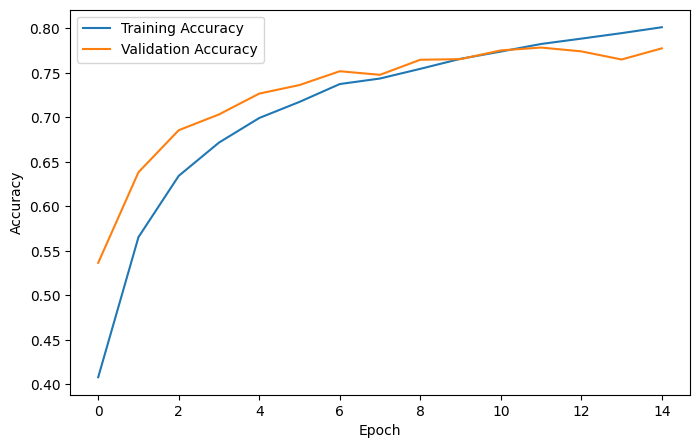

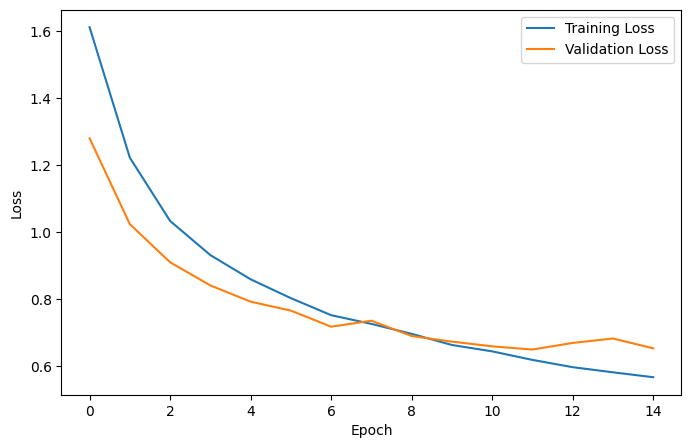

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Display Sample Images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

# Build CNN Model
model = models.Sequential()

# First Convolution Block
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Second Convolution Block
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(
    512,
    activation='relu'
))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(
    10,
    activation='softmax'
))

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()